# Day 2 — Linear Regression from Scratch (NumPy)
**Date:** 2026-06-24 · **Phase:** 1 — ML Foundations · **Tracker reference:** Day 2

**Today's goal:** understand linear and logistic regression and how a model learns its numbers (gradient descent), build linear regression from scratch by hand, and connect regularization and evaluation metrics back to the Iris work from Day 1.

This notebook lives in `01-ml-foundations-iris/notebooks/` as a second notebook — no new repo needed, this is a small building-block exercise on the way to the bigger NumPy MLP later this week.

## 1. Linear regression — what's actually happening

The model makes a prediction by multiplying each feature by a **weight** (how much that feature matters) and adding one extra number called the **bias** (a starting point, even if every feature were zero):

$$\hat{y} = w \cdot x + b$$

(With more than one feature, $w$ becomes a list of weights — one per feature — but the idea is the same: multiply each feature by its weight, add them up, then add the bias.)

**How do we know if the model is doing well?** We check how far off its predictions are, using the average squared error (squaring makes big mistakes count more, and stops positive and negative errors from cancelling out):

$$J = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2$$

The $\frac{1}{2}$ out front is just there to make the math a little tidier later — it has no real effect on what counts as a good fit.

**There are two ways to find good values for $w$ and $b$:**

1. **Solve it directly in one shot.** With a bit of matrix algebra you can jump straight to the exact answer — no trial and error. The catch: it involves inverting a matrix, which gets slow once you have a lot of features.
2. **Gradient descent** — start with a guess, then nudge $w$ and $b$ a small step in whichever direction reduces the error, and repeat:

$$w := w - \alpha \cdot dw, \qquad b := b - \alpha \cdot db$$

where $\alpha$ (the **learning rate**) controls how big each step is, and $dw$, $db$ tell us which direction reduces the error. This is the approach that scales — it's the same idea used to train everything from this simple model up to deep neural networks.

We'll build both below and check they land on the same answer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4)

## 2. Some made-up data to learn from

We'll create simple data where we already know the right answer ($y = 4 + 3x + \text{a little random noise}$). That way we can check our model actually finds something close to 4 and 3, instead of just trusting the numbers blindly.

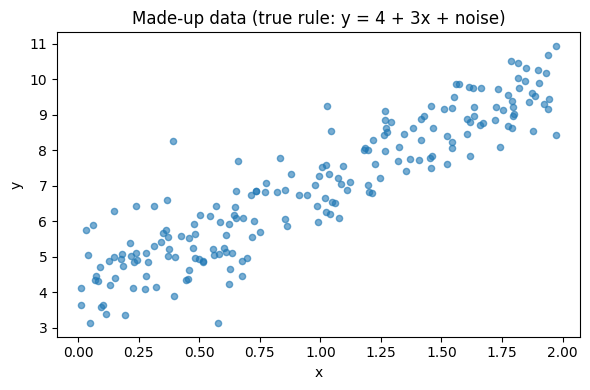

In [2]:
m = 200
X = 2 * np.random.rand(m, 1)                    # one feature, values between 0 and 2
true_bias, true_weight = 4.0, 3.0
y = true_bias + true_weight * X + np.random.randn(m, 1) * 0.8    # add some noise
y = y.ravel()   # flatten to a plain 1-D array of length m, to match X.shape[0]

plt.scatter(X, y, alpha=0.6, s=20)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Made-up data (true rule: y = 4 + 3x + noise)")
plt.tight_layout()
plt.savefig("images/linear_data.png", dpi=120)
plt.show()

## 3. Solving it directly (no step-by-step guessing)

To use the one-shot matrix formula, we temporarily stick a column of 1s onto $X$ — that's just a trick so the bias can be solved for using the same matrix multiply as the weights. Once we have the answer, we immediately split it back into the bias and the weight we actually care about, so the rest of the notebook can talk about them separately — same as the gradient descent version below.

In [3]:
X_with_ones = np.c_[np.ones((m, 1)), X]   # temporary column of 1s, just for this formula

# the one-shot formula: solve for [bias, weight] together, then split them apart
solved = np.linalg.pinv(X_with_ones.T @ X_with_ones) @ X_with_ones.T @ y
direct_bias, direct_weight = solved[0], solved[1]

print(f"Direct solution -> bias: {direct_bias:.4f}   weight: {direct_weight:.4f}")

Direct solution -> bias: 4.0842   weight: 2.9688


## 4. Gradient descent — building it step by step

This version keeps `weights` and `bias` as two separate, clearly-named things — which is how you'll see this written almost everywhere else (scikit-learn, PyTorch, and the NumPy MLP coming up on Day 6). Each step looks at the whole dataset at once ("batch" gradient descent), so we'll also save the error at every step to see it shrink.

In [4]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.cost_history = []   # error at every step, just for plotting later

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0.0

        for _ in range(self.n_iters):
            y_pred = np.dot(X, self.weights) + self.bias
            error = y_pred - y

            cost = (1 / (2 * m)) * np.sum(error ** 2)
            self.cost_history.append(cost)

            dw = (1 / m) * np.dot(X.T, error)   # which way to nudge the weights
            db = (1 / m) * np.sum(error)        # which way to nudge the bias

            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        return self

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias


gd_model = LinearRegressionScratch(learning_rate=0.5, n_iters=200)
gd_model.fit(X, y)
print(f"Gradient descent -> bias: {gd_model.bias:.4f}   weight: {gd_model.weights[0]:.4f}")

Gradient descent -> bias: 4.0842   weight: 2.9688


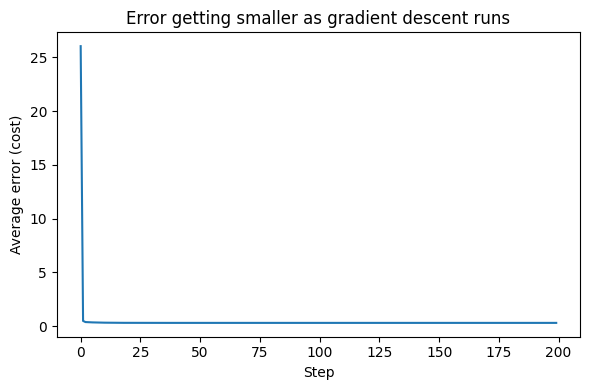

Error at step 1: 26.0307  ->  error at the end: 0.2988


In [5]:
plt.plot(gd_model.cost_history)
plt.xlabel("Step"); plt.ylabel("Average error (cost)")
plt.title("Error getting smaller as gradient descent runs")
plt.tight_layout()
plt.savefig("images/gd_cost_curve.png", dpi=120)
plt.show()
print(f"Error at step 1: {gd_model.cost_history[0]:.4f}  ->  error at the end: {gd_model.cost_history[-1]:.4f}")

## 5. Double-checking against scikit-learn

If our two from-scratch methods are right, they should land close to scikit-learn's own `LinearRegression` (which solves it directly, similar to our one-shot version above) — and all three should land close to the true values we used to make the data (bias = 4, weight = 3).

In [6]:
sklearn_model = SklearnLinearRegression()
sklearn_model.fit(X, y)

print(f"{'Method':<22}{'bias':>10}{'weight':>10}")
print(f"{'Direct solution':<22}{direct_bias:>10.4f}{direct_weight:>10.4f}")
print(f"{'Gradient descent':<22}{gd_model.bias:>10.4f}{gd_model.weights[0]:>10.4f}")
print(f"{'scikit-learn':<22}{sklearn_model.intercept_:>10.4f}{sklearn_model.coef_[0]:>10.4f}")
print(f"\n(The data was generated from bias=4, weight=3 — the small gap is just the "
      f"random noise we added, not a mistake in any of the three methods.)")

Method                      bias    weight
Direct solution           4.0842    2.9688
Gradient descent          4.0842    2.9688
scikit-learn              4.0842    2.9688

(The data was generated from bias=4, weight=3 — the small gap is just the random noise we added, not a mistake in any of the three methods.)


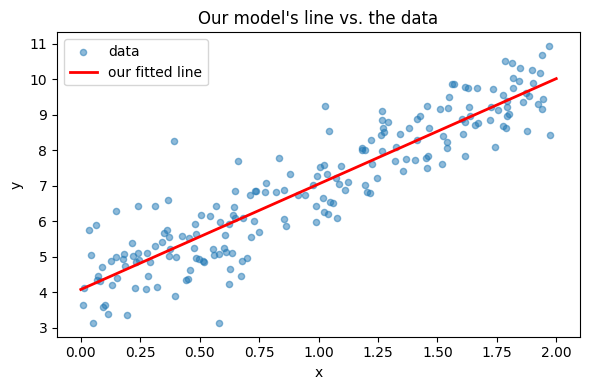

In [7]:
plt.scatter(X, y, alpha=0.5, s=20, label="data")
x_line = np.array([[0], [2]])
plt.plot(x_line, gd_model.predict(x_line), "r-", linewidth=2, label="our fitted line")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Our model's line vs. the data")
plt.legend()
plt.tight_layout()
plt.savefig("images/linear_fit.png", dpi=120)
plt.show()

## 6. Three ways to run gradient descent *(interview question)*

Each step needs to decide which direction to nudge the weights — and that decision can be based on looking at all the data, one example, or somewhere in between:

| Way | Looks at, each step | What you get |
|---|---|---|
| **Batch** | the *whole* dataset | Smooth, steady progress — but slow if you have a huge dataset, since every step means scanning everything. |
| **Stochastic (SGD)** | just *one* random example | Very cheap per step, but jumpy — it zig-zags toward the answer instead of moving smoothly. That jumpiness can actually help it avoid getting stuck in a bad spot. |
| **Mini-batch** | a small random *handful* (say, 32–256 examples) | The usual choice in practice — much smoother than one example, much cheaper than the whole dataset. This is what almost all deep learning training uses. |

Let's see the difference by shrinking how much data each step looks at, and watching the error curve get jumpier.

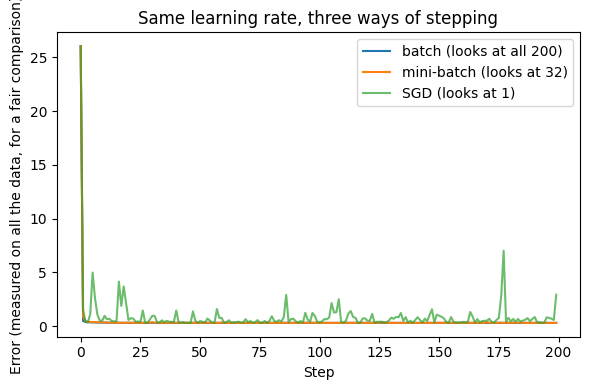

In [8]:
def run_gradient_descent(X, y, lr=0.5, n_iters=200, batch_size=None, seed=0):
    # batch_size=None means look at everything each step (batch).
    # batch_size=1 means look at one example each step (SGD).
    # anything else is mini-batch.
    rng = np.random.RandomState(seed)
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0.0
    cost_history = []
    size = m if batch_size is None else batch_size

    for _ in range(n_iters):
        idx = rng.choice(m, size=size, replace=False)
        X_sample, y_sample = X[idx], y[idx]

        sample_pred = np.dot(X_sample, weights) + bias
        sample_error = sample_pred - y_sample

        full_pred = np.dot(X, weights) + bias              # used only to track progress fairly
        cost_history.append((1 / (2 * m)) * np.sum((full_pred - y) ** 2))

        dw = (1 / size) * np.dot(X_sample.T, sample_error)
        db = (1 / size) * np.sum(sample_error)
        weights -= lr * dw
        bias -= lr * db

    return weights, bias, cost_history

_, _, history_batch = run_gradient_descent(X, y, batch_size=None)
_, _, history_mini  = run_gradient_descent(X, y, batch_size=32)
_, _, history_sgd    = run_gradient_descent(X, y, batch_size=1)

plt.plot(history_batch, label="batch (looks at all 200)")
plt.plot(history_mini, label="mini-batch (looks at 32)")
plt.plot(history_sgd, label="SGD (looks at 1)", alpha=0.7)
plt.xlabel("Step"); plt.ylabel("Error (measured on all the data, for a fair comparison)")
plt.title("Same learning rate, three ways of stepping")
plt.legend()
plt.tight_layout()
plt.savefig("images/gd_variants.png", dpi=120)
plt.show()

Batch gives the smoothest line, SGD is clearly the jumpiest, and mini-batch sits in between — matching the table above. (All three use the same learning rate here just to make the difference easy to see — in practice SGD and mini-batch are usually run with a smaller learning rate and many more, cheaper steps.)

## 7. Logistic regression — how it's related *(just theory today, no build required)*

Linear regression predicts any number. Logistic regression reuses the exact same weighted-sum idea, but squeezes the result into a number between 0 and 1 using a function called **sigmoid**, so it can be read as a probability:

$$\text{sigmoid}(z) = \frac{1}{1 + e^{-z}}, \qquad \hat{p} = \text{sigmoid}(w \cdot x + b)$$

Instead of average squared error, it's trained with a cost function called **log-loss** (sometimes called cross-entropy), which is harsher than squared error specifically toward confident-but-wrong answers:

$$J = -\frac{1}{m}\sum_{i=1}^{m}\Big[y^{(i)}\log(\hat{p}^{(i)}) + (1-y^{(i)})\log(1-\hat{p}^{(i)})\Big]$$

Here's the neat part: the nudge-direction formulas ($dw$, $db$) end up looking **exactly the same shape** as linear regression's — just using $\hat{p}$ (the sigmoid output) instead of $\hat{y}$. So the `LinearRegressionScratch` class above is most of the way to a logistic regression class already: swap in sigmoid, swap in log-loss, and the step-by-step loop barely changes. That's a good one to try once trees and ensembles (Day 3) are out of the way.

This is also exactly what Day 1's `LogisticRegression` on Iris was doing underneath — just stretched to handle 3 flower types instead of one yes/no answer.

## 8. Keeping weights from growing too large *(interview question)*

Sometimes a model fits the training data *too* closely, including its noise, by letting some weights grow very large. **Regularization** adds a small penalty for large weights, so the model has to "earn" a large weight by it actually being useful:

$$J_{\text{ridge}} = J + \lambda\sum (\text{weight})^2 \qquad\qquad J_{\text{lasso}} = J + \lambda\sum |\text{weight}|$$

| | L2 (called Ridge) | L1 (called Lasso) |
|---|---|---|
| What it penalizes | the *square* of each weight | the *size* (absolute value) of each weight |
| Effect | shrinks weights toward zero, smoothly | can push some weights to **exactly** zero |
| Good for | "most features matter a little" | automatically dropping the features that don't matter |
| Using both at once | called **ElasticNet** | |

Here's that "exactly zero" effect in action, on made-up data where some features genuinely don't matter at all: 

In [9]:
from sklearn.linear_model import Ridge, Lasso

rng = np.random.RandomState(0)
m2, n_features = 60, 10
X_demo = rng.randn(m2, n_features)
true_w = np.array([5, -3, 0, 0, 2, 0, 0, 0, 1.5, 0])   # only 4 of these 10 features matter
y_demo = X_demo @ true_w + rng.randn(m2) * 0.5

ridge = Ridge(alpha=2.0).fit(X_demo, y_demo)
lasso = Lasso(alpha=0.5).fit(X_demo, y_demo)

print(f"{'feature':<10}{'true weight':>12}{'ridge':>10}{'lasso':>10}")
for i in range(n_features):
    print(f"x{i:<9}{true_w[i]:>12.1f}{ridge.coef_[i]:>10.3f}{lasso.coef_[i]:>10.3f}")
print(f"\nLasso set {(np.abs(lasso.coef_) < 1e-8).sum()} of {n_features} weights to exactly zero — "
      f"and those line up with the features that were genuinely useless.")

feature    true weight     ridge     lasso
x0                 5.0     4.679     4.270
x1                -3.0    -2.810    -2.099
x2                 0.0     0.075     0.000
x3                 0.0     0.040     0.000
x4                 2.0     1.786     1.170
x5                 0.0    -0.086    -0.000
x6                 0.0     0.064     0.000
x7                 0.0    -0.054    -0.000
x8                 1.5     1.297     0.727
x9                 0.0     0.164     0.000

Lasso set 6 of 10 weights to exactly zero — and those line up with the features that were genuinely useless.


## 9. Checking how good a classifier really is *(theory recall)*

For a yes/no style prediction, every mistake falls into one of four buckets:

| | Predicted yes | Predicted no |
|---|---|---|
| **Actually yes** | correct (TP) | missed it (FN) |
| **Actually no** | false alarm (FP) | correct (TN) |

$$\text{Accuracy} = \frac{\text{correct}}{\text{everything}} \qquad \text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN}$$

$$F1 = 2 \cdot \frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}$$

**Plain-English versions:**
- **Precision** — "of the times the model said yes, how often was it actually right?" Matters most when a false alarm is costly (e.g. wrongly flagging someone's payment as fraud).
- **Recall** — "of all the actual yeses, how many did the model catch?" Matters most when missing one is costly (e.g. missing an actual illness).
- **F1** — one number that blends precision and recall, and drops sharply if either one is weak. Useful when you need a single score and the classes aren't evenly split — plain accuracy can be misleading there.
- **ROC-AUC** — roughly: "if I picked one real yes and one real no at random, how often would the model correctly rank the yes higher?" It checks the model's sense of ranking, not just its final yes/no cutoff.

Let's check all of these on Day 1's exact Iris setup (same split, same model), instead of just accuracy: 

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

clf = LogisticRegression(max_iter=200).fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

print(classification_report(y_test, y_pred, target_names=iris.target_names))

y_test_as_columns = label_binarize(y_test, classes=[0, 1, 2])
auc = roc_auc_score(y_test_as_columns, y_proba, multi_class="ovr")
print(f"Average ROC-AUC across the 3 flower types: {auc:.4f}")

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Average ROC-AUC across the 3 flower types: 1.0000


On Iris, precision/recall/F1 stay close to Day 1's 0.9667 accuracy — which makes sense, since Iris is a clean, evenly-split dataset with no class that's more important to catch than another. The gap between accuracy and these other numbers shows up far more on lopsided data, which is exactly why Day 3 covers how to handle imbalanced datasets.

## 10. What was built and learned today

**Built:**
- `LinearRegressionScratch`: gradient descent linear regression, written from scratch in NumPy with separate `weights` and `bias`, checked against both the direct one-shot formula and scikit-learn's own `LinearRegression` — all three agree.
- A side-by-side look at batch, mini-batch, and SGD on the same data, showing the smooth-vs-jumpy tradeoff directly instead of just describing it.

**Learned:**
- Two ways to find good weights: solve directly in one shot, or take small steps with gradient descent — and why gradient descent is the one that scales.
- The three ways of running gradient descent, and when each is used.
- Logistic regression is linear regression's sibling — same weighted sum, squeezed through sigmoid, trained with log-loss instead of squared error.
- L1 (Lasso) can zero out useless weights entirely; L2 (Ridge) only shrinks them — seen directly in code, not just described.
- Precision, recall, F1, and ROC-AUC, checked on the actual Day 1 Iris model instead of just defined in the abstract.

**Next up (Day 3):** decision trees, random forests, and gradient boosting — Project 2 (tabular data + XGBoost), bagging vs. boosting, handling lopsided datasets, and the different flavors of cross-validation (k-fold, stratified, time-series).

**Save into the repo as:** `01-ml-foundations-iris/notebooks/02_linear_regression_scratch.ipynb`, with the four PNGs going into that repo's `images/` folder (`linear_data.png`, `gd_cost_curve.png`, `linear_fit.png`, `gd_variants.png`) — same filenames as before, this version replaces the earlier draft.